In [165]:
import numpy as np
import matplotlib.pyplot as plt

# Setup

### Domain Setup

Grid spacing (dx): 0.02
Time step size (dt): 0.016
Total simulation time (T): 1.6


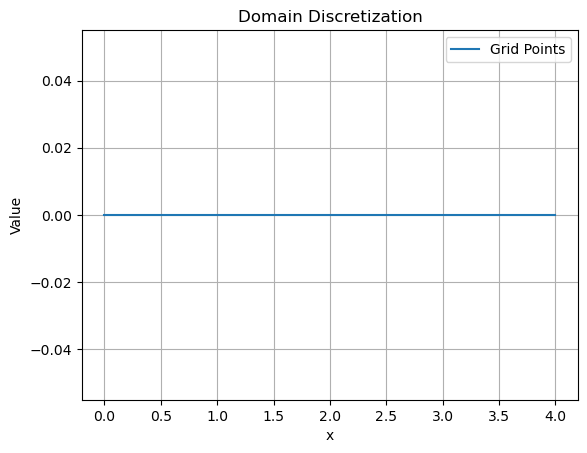

In [166]:
L = 4 # Length of the domain
N = 200 # Number of grid points

dx = L / N # Grid spacing

print("Grid spacing (dx):", dx)

x = np.linspace(0, L, N) # Grid points

c = 1.0
cfl = 0.8 # CFL number

dt = cfl * dx / c # Time step size
print("Time step size (dt):", dt)

nt = 100 # Number of time steps
T = nt * dt # Total simulation time
print("Total simulation time (T):", T)

plt.plot(x, np.zeros_like(x), label='Grid Points')
plt.title('Domain Discretization')
plt.xlabel('x')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

### INITIAL CONDITION: A Gaussian pulse

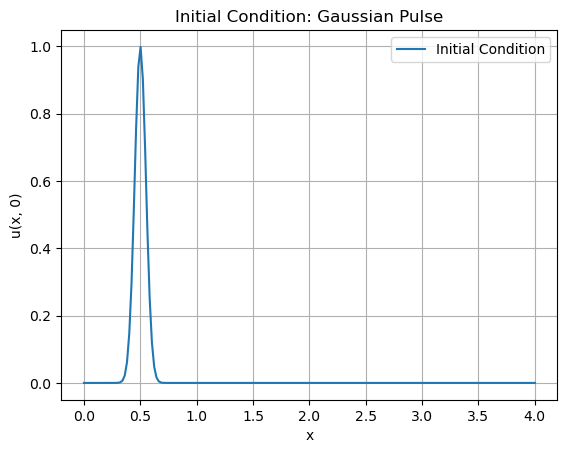

In [167]:
x0 = 0.5 # Initial position of the pulse
sigma = 0.05 # Width of the pulse

u0 = np.exp(-((x - x0) ** 2) / (2 * sigma ** 2)) # Initial condition
plt.plot(x, u0, label='Initial Condition')
plt.title('Initial Condition: Gaussian Pulse')
plt.xlabel('x')
plt.ylabel('u(x, 0)')
plt.legend()
plt.grid()
plt.show()

## Solver - FTBS

In [168]:
def advection_ftbs(u, c, dt, dx):
    u_new = np.copy(u)
    u_new[1:] = u[1:] - c * dt / dx * (u[1:] - u[:-1]) # FTBS scheme
    u_new[0] = u[0] - c * dt / dx * (u[0] - u[-1]) # Periodic boundary condition
    return u_new


u = np.copy(u0) # Initialize the solution with the initial condition
u_history = [u.copy()] # Store the solution history for plotting
for n in range(nt):
    u = advection_ftbs(u, c, dt, dx) # Update the solution using the FTBS scheme
    u_history.append(u.copy()) # Store the solution at each time step

## Result
### Initial Plot vs Final Plot

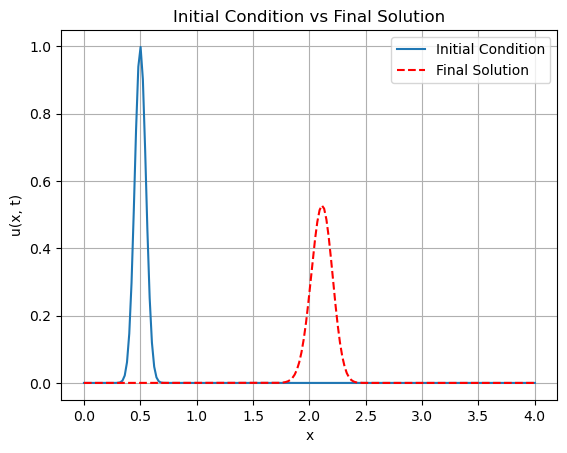

In [169]:
u0 = np.exp(-((x - x0) ** 2) / (2 * sigma ** 2)) # Initial condition
plt.plot(x, u0, label='Initial Condition')
plt.plot(x, u, label='Final Solution', linestyle='--', color='red')
plt.title('Initial Condition vs Final Solution')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.legend()
plt.grid()
plt.show()

## Exact Solution

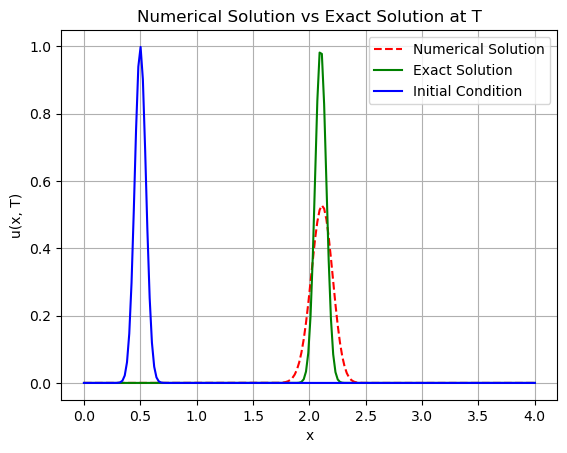

In [170]:
u_exact = np.exp(-((x - x0 - c * T) ** 2) / (2 * sigma ** 2)) # Exact solution at time T
plt.plot(x, u, label='Numerical Solution', linestyle='--', color='red')
plt.plot(x, u_exact, label='Exact Solution', linestyle='-', color='green')
plt.plot(x, u0, label='Initial Condition', linestyle='-', color='blue')
plt.title('Numerical Solution vs Exact Solution at T')
plt.xlabel('x')
plt.ylabel('u(x, T)')
plt.legend()
plt.grid()
plt.show()